In [1]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes,add_disinfo_nodes,state_to_graph, er_opinion_graph
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing,in_and_out_degree_sum,cross_type_degree
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
n, k = 10000, 150
p_er = k / (n - 1)

In [3]:
Del_et_tidskridt  = 100
Del_to_tidskridt = 100
Del_tre_tidskridt = 100

In [4]:
ws_Scenarie1 = ws_opinion_graph(n,k,seed = 11)
ws_Scenarie1matrix = create_matrix_rep(ws_Scenarie1)
ws_mask = ws_Scenarie1matrix.type =='Human'

In [5]:
er_Scenarie1 = er_opinion_graph(10000,p_er,seed = 11)
er_Scenarie1matrix = create_matrix_rep(er_Scenarie1)
er_mask = er_Scenarie1matrix.type =='Human'

In [6]:
ws_Scenarie1.opinions, ws_Scenarie1_sim_results,ws_Scenarie1_startcond,ws_Scenarie1_endcond= simpel_simulering(ws_Scenarie1matrix,Del_et_tidskridt)
er_Scenarie1.opinions, er_Scenarie1_sim_results,er_Scenarie1_startcond,er_Scenarie1_endcond= simpel_simulering(er_Scenarie1matrix,Del_et_tidskridt)

Simulating: 100%|██████████| 100/100 [00:06<00:00, 14.90it/s]


In [7]:
ws_average_opinionresult, ws_average_distance_to_the_mean_result = data_processing(ws_Scenarie1_sim_results,ws_mask)
er_average_opinionresult, er_average_distance_to_the_mean_result = data_processing(er_Scenarie1_sim_results,er_mask)


In [8]:

ws_MedierScenarie1 = add_media_nodes(ws_Scenarie1matrix,100, seed =11, factor = 1)
ws_maskmedia = ws_MedierScenarie1.type == 'Human'



In [9]:
er_MedierScenarie1 = add_media_nodes(er_Scenarie1matrix,100, seed =11, factor = 1)
er_maskmedia = er_MedierScenarie1.type == 'Human'


In [10]:
ws_MedierScenarie1.opinions, ws_MedierScenarie1_sim_results,ws_MedierScenarie1_startcond,ws_MedierScenarie1_endcond= simpel_simulering(ws_MedierScenarie1,Del_to_tidskridt)
ws_MedierScenarie1_average_opinionresult, ws_MedierScenarie1_average_distance_to_the_mean_result = data_processing(ws_MedierScenarie1_sim_results,ws_maskmedia)

Simulating: 100%|██████████| 100/100 [00:10<00:00,  9.64it/s]


In [11]:
er_MedierScenarie1.opinions, er_MedierScenarie1_sim_results,er_MedierScenarie1_startcond,er_MedierScenarie1_endcond= simpel_simulering(er_MedierScenarie1,Del_to_tidskridt)
er_MedierScenarie1_average_opinionresult, er_MedierScenarie1_average_distance_to_the_mean_result = data_processing(er_MedierScenarie1_sim_results,er_maskmedia)

Simulating: 100%|██████████| 100/100 [00:10<00:00,  9.67it/s]


In [12]:
ws_DisinfoScenarie1 = add_disinfo_nodes(ws_MedierScenarie1,100,seed = 11)
ws_maskdisinfo = ws_DisinfoScenarie1.type == 'Human'


In [13]:
er_DisinfoScenarie1 = add_disinfo_nodes(er_MedierScenarie1,100,seed = 11)
er_maskdisinfo = er_DisinfoScenarie1.type == 'Human'


In [14]:
ws_DisinfoScenarie1.opinions, ws_DisinfoScenarie1_sim_results,ws_DisinfoScenarie1_startcond,ws_DisinfoScenarie1_endcond= simpel_simulering(ws_DisinfoScenarie1,Del_tre_tidskridt)
ws_DisinfoScenarie1_average_opinionresult, ws_DisinfoScenarie1_average_distance_to_the_mean_result = data_processing(ws_DisinfoScenarie1_sim_results,ws_maskdisinfo)

Simulating: 100%|██████████| 100/100 [00:09<00:00, 10.42it/s]


In [15]:
er_DisinfoScenarie1.opinions, er_DisinfoScenarie1_sim_results,er_DisinfoScenarie1_startcond,er_DisinfoScenarie1_endcond= simpel_simulering(er_DisinfoScenarie1,Del_tre_tidskridt)
er_DisinfoScenarie1_average_opinionresult, er_DisinfoScenarie1_average_distance_to_the_mean_result = data_processing(er_DisinfoScenarie1_sim_results,er_maskdisinfo)

Simulating: 100%|██████████| 100/100 [00:09<00:00, 10.67it/s]


In [16]:
print(er_DisinfoScenarie1.matrix.shape if hasattr(er_DisinfoScenarie1, "matrix") else "check attribute name")
print(er_DisinfoScenarie1.opinions.shape)

(10200, 10200)
(10200,)


In [17]:

ws_totalgennemsnit = np.concatenate((ws_average_opinionresult,ws_MedierScenarie1_average_opinionresult,ws_DisinfoScenarie1_average_opinionresult))

ws_totalgennemgennemsnit = np.concatenate((ws_average_distance_to_the_mean_result,ws_MedierScenarie1_average_distance_to_the_mean_result,ws_DisinfoScenarie1_average_distance_to_the_mean_result))

ws_binsScenarie1 = np.histogram_bin_edges(np.concatenate([ws_Scenarie1_startcond[ws_mask], ws_Scenarie1_endcond[ws_mask],ws_MedierScenarie1_endcond[ws_maskmedia],ws_DisinfoScenarie1_endcond[ws_maskdisinfo]]), bins=100)


In [18]:

er_totalgennemsnit = np.concatenate((er_average_opinionresult,er_MedierScenarie1_average_opinionresult,er_DisinfoScenarie1_average_opinionresult))

er_totalgennemgennemsnit = np.concatenate((er_average_distance_to_the_mean_result,er_MedierScenarie1_average_distance_to_the_mean_result,er_DisinfoScenarie1_average_distance_to_the_mean_result))

er_binsScenarie1 = np.histogram_bin_edges(np.concatenate([er_Scenarie1_startcond[er_mask], er_Scenarie1_endcond[er_mask],er_MedierScenarie1_endcond[er_maskmedia],er_DisinfoScenarie1_endcond[er_maskdisinfo]]), bins=100)


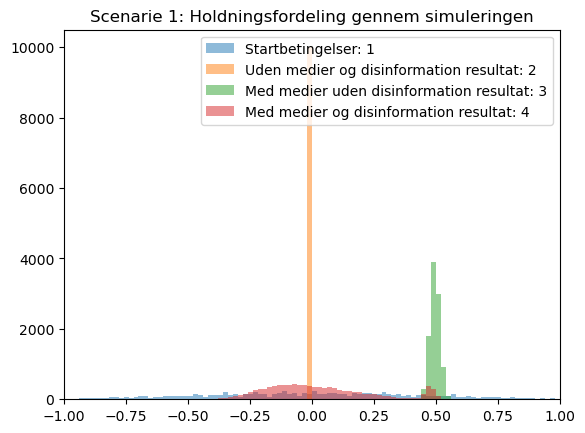

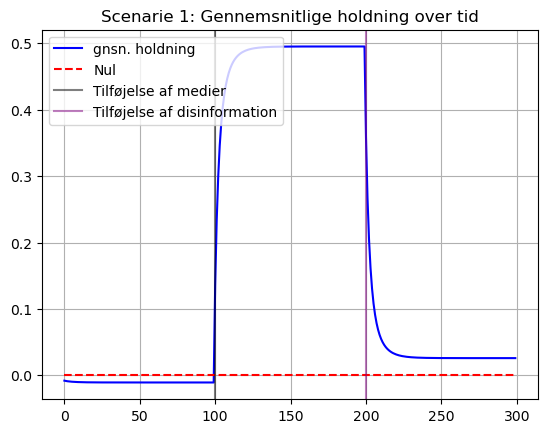

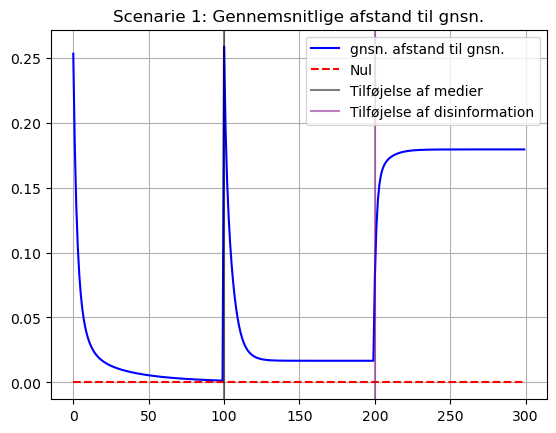

In [19]:
plt.figure()
plt.hist(ws_Scenarie1_startcond[ws_mask], bins=ws_binsScenarie1,alpha=0.5, label='Startbetingelser: 1')
plt.hist(ws_Scenarie1_endcond[ws_mask], bins=ws_binsScenarie1, alpha=0.5, label='Uden medier og disinformation resultat: 2')
plt.hist(ws_MedierScenarie1_endcond[ws_maskmedia], bins=ws_binsScenarie1, alpha=0.5, label='Med medier uden disinformation resultat: 3')
plt.hist(ws_DisinfoScenarie1_endcond[ws_maskdisinfo], bins=ws_binsScenarie1, alpha=0.5, label='Med medier og disinformation resultat: 4')

plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 1: Holdningsfordeling gennem simuleringen')
plt.show()


plt.figure()
plt.plot(np.arange(len(ws_totalgennemsnit)),ws_totalgennemsnit,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(ws_totalgennemsnit)),np.zeros(len(ws_totalgennemsnit)),'r--',label = 'Nul')
plt.axvline(x = Del_et_tidskridt,color = 'k', alpha=0.5, label = 'Tilføjelse af medier')
plt.axvline(x = Del_et_tidskridt+Del_to_tidskridt,color = 'purple', alpha=0.5, label = 'Tilføjelse af disinformation')

plt.legend(loc = 'upper left')
plt.grid()
plt.title('Scenarie 1: Gennemsnitlige holdning over tid')
plt.show()

plt.figure()
plt.plot(np.arange(len(ws_totalgennemgennemsnit)),ws_totalgennemgennemsnit,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(ws_totalgennemgennemsnit)),np.zeros(len(ws_totalgennemgennemsnit)),'r--',label = 'Nul')
plt.axvline(x = Del_et_tidskridt, color = 'k',alpha=0.5,label = 'Tilføjelse af medier')
plt.axvline(x = Del_et_tidskridt+Del_to_tidskridt,color = 'purple', alpha=0.5,label = 'Tilføjelse af disinformation')

plt.legend()
plt.grid()
plt.title('Scenarie 1: Gennemsnitlige afstand til gnsn.')
plt.show()

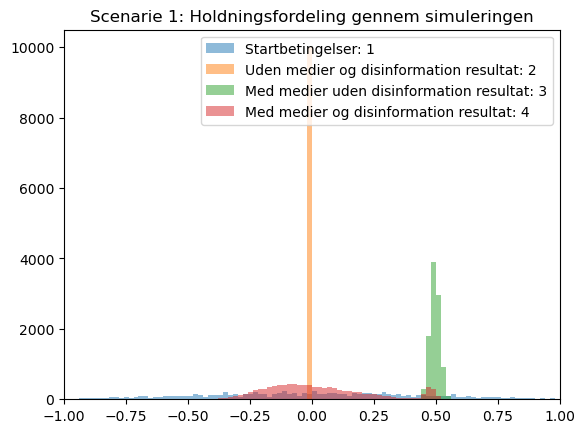

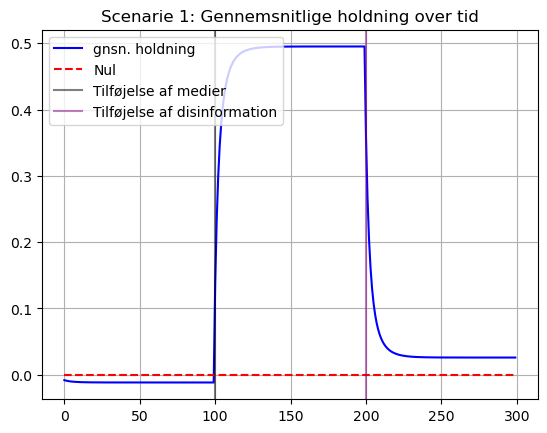

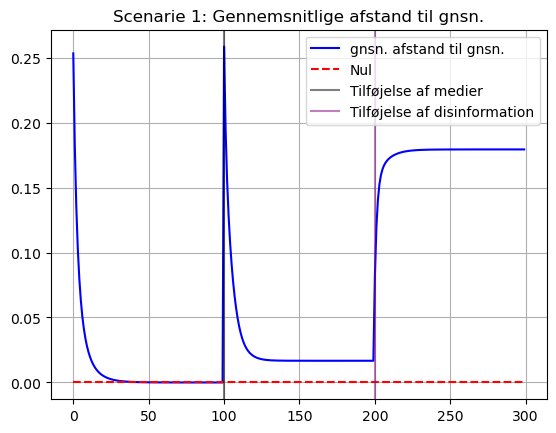

In [20]:
plt.figure()
plt.hist(er_Scenarie1_startcond[er_mask], bins=er_binsScenarie1,alpha=0.5, label='Startbetingelser: 1')
plt.hist(er_Scenarie1_endcond[er_mask], bins=er_binsScenarie1, alpha=0.5, label='Uden medier og disinformation resultat: 2')
plt.hist(er_MedierScenarie1_endcond[er_maskmedia], bins=er_binsScenarie1, alpha=0.5, label='Med medier uden disinformation resultat: 3')
plt.hist(er_DisinfoScenarie1_endcond[er_maskdisinfo], bins=er_binsScenarie1, alpha=0.5, label='Med medier og disinformation resultat: 4')

plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 1: Holdningsfordeling gennem simuleringen')
plt.show()


plt.figure()
plt.plot(np.arange(len(er_totalgennemsnit)),er_totalgennemsnit,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(er_totalgennemsnit)),np.zeros(len(er_totalgennemsnit)),'r--',label = 'Nul')
plt.axvline(x = Del_et_tidskridt,color = 'k', alpha=0.5, label = 'Tilføjelse af medier')
plt.axvline(x = Del_et_tidskridt+Del_to_tidskridt,color = 'purple', alpha=0.5, label = 'Tilføjelse af disinformation')

plt.legend(loc = 'upper left')
plt.grid()
plt.title('Scenarie 1: Gennemsnitlige holdning over tid')
plt.show()

plt.figure()
plt.plot(np.arange(len(er_totalgennemgennemsnit)),er_totalgennemgennemsnit,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(er_totalgennemgennemsnit)),np.zeros(len(er_totalgennemgennemsnit)),'r--',label = 'Nul')
plt.axvline(x = Del_et_tidskridt, color = 'k',alpha=0.5,label = 'Tilføjelse af medier')
plt.axvline(x = Del_et_tidskridt+Del_to_tidskridt,color = 'purple', alpha=0.5,label = 'Tilføjelse af disinformation')

plt.legend()
plt.grid()
plt.title('Scenarie 1: Gennemsnitlige afstand til gnsn.')
plt.show()